## Import the Libraries 

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("D:\AI Health Prediction\diabetes-prediction-master\data\heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Basic Analysis

**Shape of the Dataset**


In [3]:
df.shape

(920, 16)

**Getting the stastical summary of the Data**

In [4]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## Drop Unnecessary Columns

In [6]:
df.drop(columns=['id', 'dataset','ca','thal'], errors='ignore', inplace=True)
df.head(5)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


## Missing Values Check

In [7]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
num           0
dtype: int64

## Handle Missing Values

**Numerical Columns**

In [8]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

**Categorical Columns**

In [9]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df.head(5)

C:\Users\agraw\AppData\Local\Temp\ipykernel_12488\2159778458.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

## Encode Categorical Columns

In [11]:
encoder = LabelEncoder()

categorical_columns = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,2
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0


## Visualization

**Countplot**

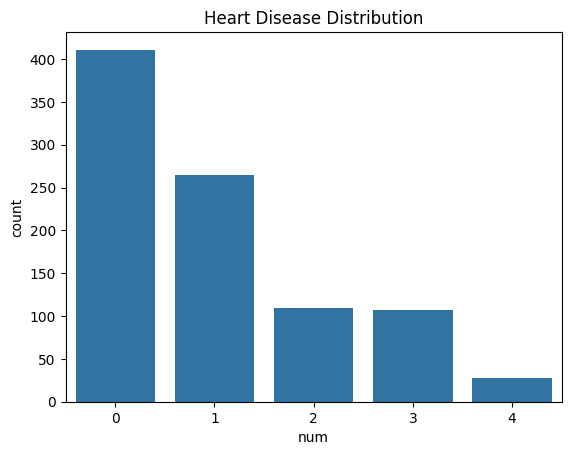

In [12]:
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

**Histogram**

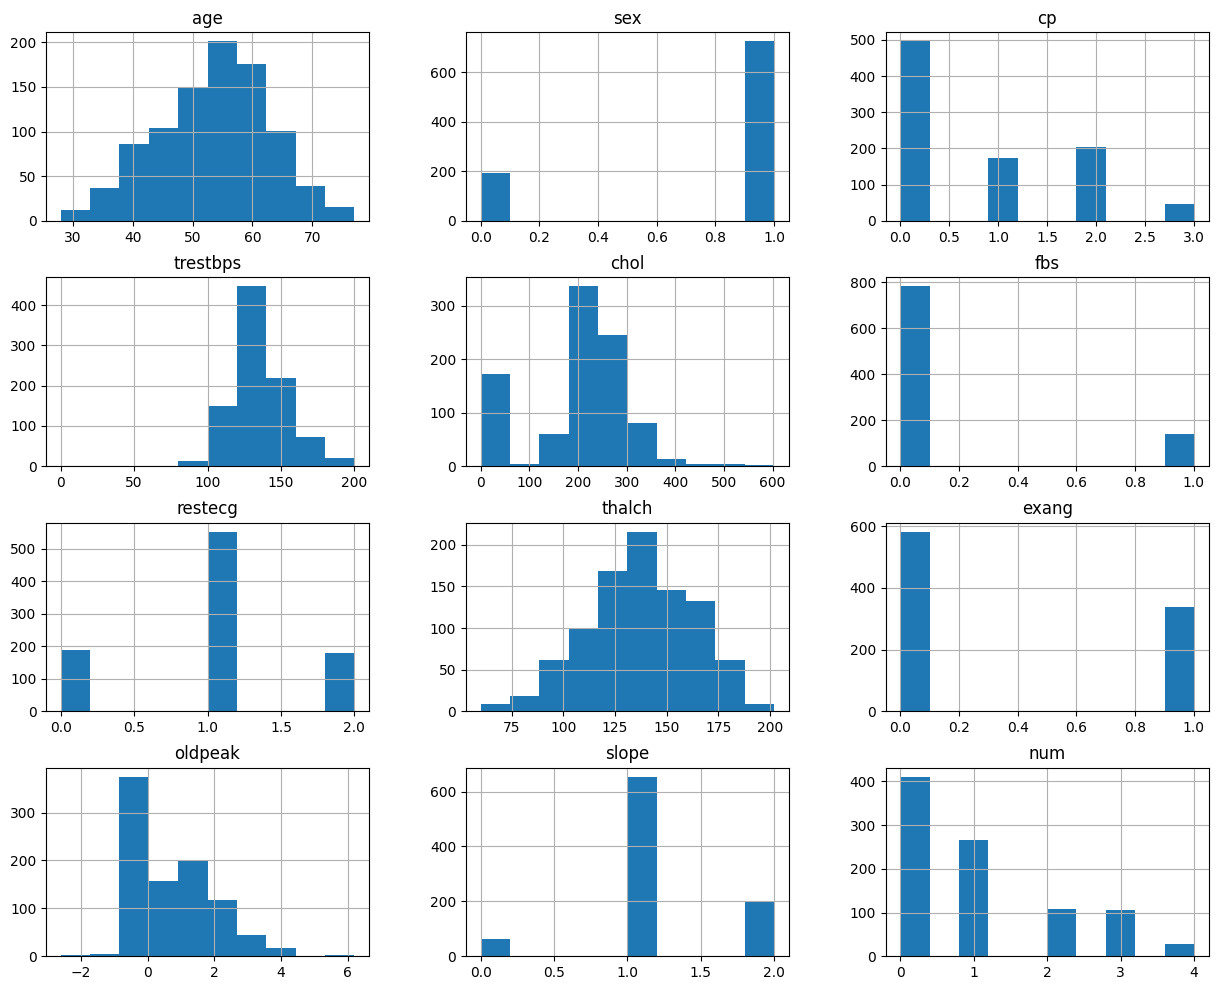

In [13]:
df.hist(figsize=(15,12))
plt.show()

**Heatmap**

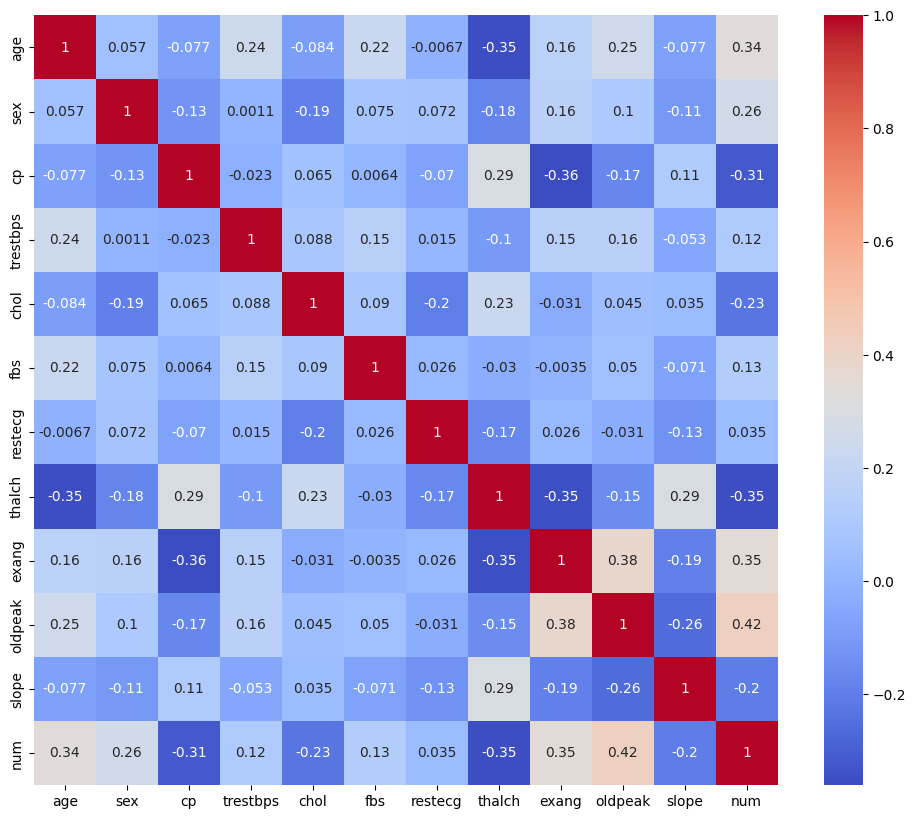

In [14]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [15]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
df['num'].value_counts()

num
1    509
0    411
Name: count, dtype: int64

# ML Pipeline

### X and y Split

In [16]:
X = df.drop('num', axis=1)
y = df['num']

### Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Feature Scaling

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Training

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

**Initialize Models**

In [20]:
lr_model = LogisticRegression()

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

svm_model = SVC()

knn_model = KNeighborsClassifier()

**Train Models**

In [21]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", round(acc * 100, 2))

    print(confusion_matrix(y_test, preds))

    print(classification_report(y_test, preds))


Logistic Regression
Accuracy: 77.72
[[59 16]
 [25 84]]
              precision    recall  f1-score   support

           0       0.70      0.79      0.74        75
           1       0.84      0.77      0.80       109

    accuracy                           0.78       184
   macro avg       0.77      0.78      0.77       184
weighted avg       0.78      0.78      0.78       184


Random Forest
Accuracy: 82.07
[[62 13]
 [20 89]]
              precision    recall  f1-score   support

           0       0.76      0.83      0.79        75
           1       0.87      0.82      0.84       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.83      0.82      0.82       184


SVM
Accuracy: 85.33
[[63 12]
 [15 94]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        75
           1       0.89      0.86      0.87       109

    accuracy                        

### Best Model Selection

In [22]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: SVM


### Save Model

In [23]:
import pickle

pickle.dump(best_model, open('heart_model.pkl', 'wb'))

pickle.dump(scaler, open('heart_scaler.pkl', 'wb'))